# 03 · Preprocessing

Clean and normalise the data so it is ready for statistical analysis and ML.

Steps:
1. **Feature filtering** — remove features with m/z ≤ 500 Da, detection rate < 70 %, or QC CV ≥ 30 %
2. **Sample QC filtering** — remove samples with excessive missing values or outlier TIC
3. **Missing value imputation** — replace zeros with half the per-feature minimum
4. **Log2 transformation**
5. **PQN normalisation** (Probabilistic Quotient Normalisation)
6. **Batch correction** (ComBat)

**Input:** `files/data/processed/raw_aligned.pkl`  
**Output:** `files/data/processed/clean_matrix.pkl`, `files/data/processed/normalized_matrix.pkl`

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

DATA_DIR = Path("../files/data")
FIG_DIR  = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_COLORS = {
    "French": "#d62728", "LMU": "#ff7f0e", "Dunn": "#2ca02c",
    "QC": "#1f77b4", "dQC": "#9467bd", "B": "#7f7f7f", "SS": "#bcbd22",
}
CLASS_LABEL = {
    "French": "Disease (lung cancer)", "LMU": "Benign (pulmonary disease)",
    "Dunn": "Control (healthy)", "QC": "Pooled QC",
    "dQC": "Diluted QC", "B": "Blank", "SS": "System suitability",
}
BIO_CLASSES = ["French", "LMU", "Dunn"]

print("Setup complete.")

Setup complete.


In [2]:
with open(DATA_DIR / "processed/raw_aligned.pkl", "rb") as f:
    raw = pickle.load(f)

data_matrix  = raw["data_matrix"]
feature_meta = raw["feature_meta"]
sample_meta  = raw["sample_meta"]
standards    = raw["standards"]

print(f"Loaded: {data_matrix.shape[0]} samples x {data_matrix.shape[1]} features")
print(f"Classes: {dict(sample_meta['class'].value_counts())}")

Loaded: 102 samples x 252 features
Classes: {'Dunn': np.int64(27), 'French': np.int64(26), 'LMU': np.int64(26), 'QC': np.int64(11), 'B': np.int64(6), 'dQC': np.int64(5), 'SS': np.int64(1)}


## 1 · Feature Filtering

Three sequential filters are applied to remove analytically unreliable features:

| Filter | Criterion | Rationale |
|--------|-----------|-----------|
| **Mass range** | m/z > 500 Da | Glycan-sized molecules; below 500 Da are small molecules / contaminants |
| **Prevalence** | >= 70% detection in at least one biological class | Features near the detection limit lack reliable quantification |
| **Reproducibility** | QC CV < 30% | High CV indicates instrument noise dominates the signal |

Filters are applied in sequence; the surviving feature set is used for all downstream steps.

In [3]:
QC_IDX    = sample_meta[sample_meta["class"] == "QC"].index
BIO_IDX   = sample_meta[sample_meta["class"].isin(BIO_CLASSES)].index
BLANK_IDX = sample_meta[sample_meta["class"] == "B"].index

dm_qc    = data_matrix.loc[QC_IDX]
dm_bio   = data_matrix.loc[BIO_IDX]
dm_blank = data_matrix.loc[BLANK_IDX]

# ── Filter 1: m/z > 500 Da ───────────────────────────────────────────────
pass_mz = feature_meta["mz"] > 500
print(f"Filter 1 – m/z > 500 Da          : {pass_mz.sum():>3d} / {len(pass_mz)} pass  "
      f"({(~pass_mz).sum()} removed)")

# ── Filter 2: prevalence >= 70% in at least one bio class ────────────────
class_detect = {}
for cls in BIO_CLASSES:
    idx = sample_meta[sample_meta["class"] == cls].index
    class_detect[cls] = (data_matrix.loc[idx] > 0).mean()
detect_df   = pd.DataFrame(class_detect)
pass_prev   = (detect_df.max(axis=1) >= 0.70)
print(f"Filter 2 – prevalence >= 70%      : {pass_prev.sum():>3d} / {len(pass_prev)} pass  "
      f"({(~pass_prev).sum()} removed)")

# ── Filter 3: QC CV < 30% ────────────────────────────────────────────────
qc_nz   = dm_qc.replace(0, np.nan)
qc_cv   = (qc_nz.std() / qc_nz.mean() * 100).fillna(np.inf)
pass_cv = qc_cv < 30.0
print(f"Filter 3 – QC CV < 30%            : {pass_cv.sum():>3d} / {len(pass_cv)} pass  "
      f"({(~pass_cv).sum()} removed)")

# ── Filter 4: contamination — blank/bio mean <= 30% ──────────────────────
blank_mean      = dm_blank.replace(0, np.nan).mean(axis=0).fillna(0.0)
bio_mean_f      = dm_bio.replace(0, np.nan).mean(axis=0)
blank_bio_ratio = (blank_mean / bio_mean_f).fillna(1.0)
pass_contam     = blank_bio_ratio <= 0.30
print(f"Filter 4 – contamination <= 30%   : {pass_contam.sum():>3d} / {len(pass_contam)} pass  "
      f"({(~pass_contam).sum()} removed)")

# ── Combined (all 4 filters, sequential) ────────────────────────────────
pass_all   = pass_mz & pass_prev & pass_cv & pass_contam
good_feats = pass_all[pass_all].index

print(f"\nFinal feature set after all 4 filters : {len(good_feats)} features")
print(f"  Removed total : {len(pass_all) - len(good_feats)} features")

feature_meta_filt = feature_meta.loc[good_feats]
data_filt         = data_matrix[good_feats]

Filter 1 – m/z > 500 Da          : 248 / 252 pass  (4 removed)
Filter 2 – prevalence >= 70%      : 252 / 252 pass  (0 removed)
Filter 3 – QC CV < 30%            : 197 / 252 pass  (55 removed)
Filter 4 – contamination <= 30%   : 252 / 252 pass  (0 removed)

Final feature set after all 4 filters : 194 features
  Removed total : 58 features


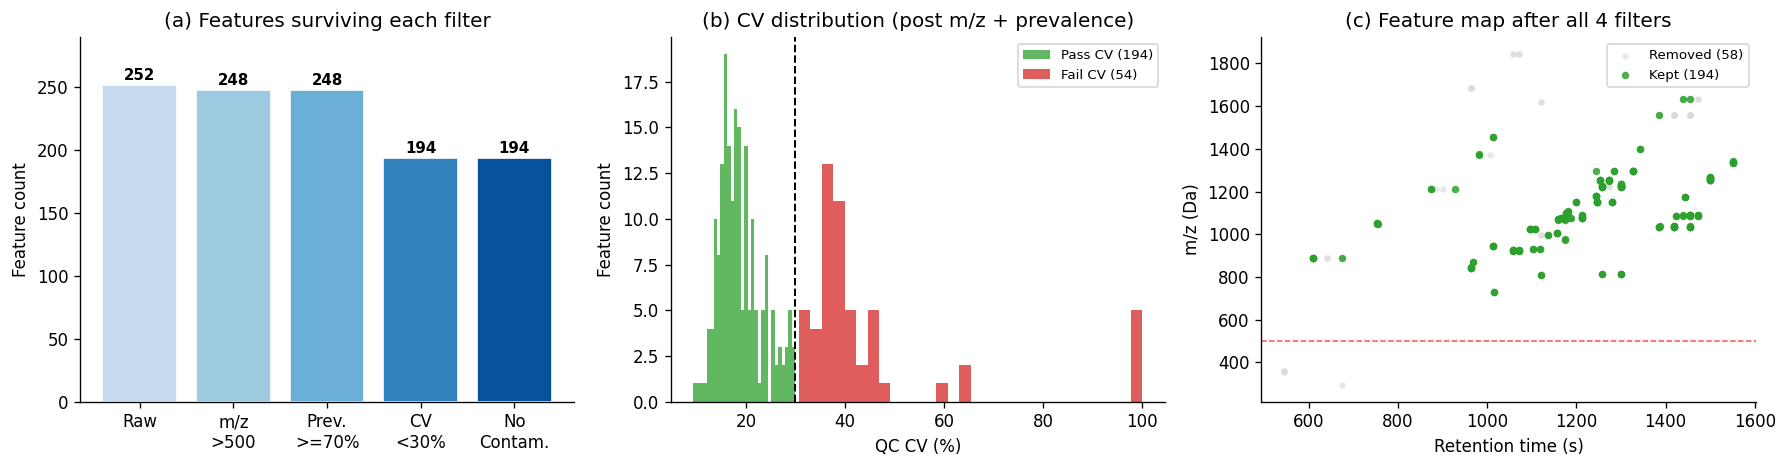

m/z range (kept) : 728.0 – 1633.0 Da
RT range  (kept) : 609 – 1551 s


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── (a) Waterfall: features surviving each filter (all 4) ─────────────────
ax = axes[0]
stages = ["Raw", "m/z\n>500", "Prev.\n>=70%", "CV\n<30%", "No\nContam."]
counts = [
    len(pass_mz),
    pass_mz.sum(),
    (pass_mz & pass_prev).sum(),
    (pass_mz & pass_prev & pass_cv).sum(),
    pass_all.sum(),
]
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]
bars = ax.bar(stages, counts, color=colors, edgecolor="white")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Feature count")
ax.set_title("(a) Features surviving each filter")
ax.set_ylim(0, len(pass_mz) * 1.15)

# ── (b) CV distribution, coloured by pass/fail ───────────────────────────
ax = axes[1]
cv_plot  = qc_cv.clip(upper=100).replace([np.inf], 100)
eligible = pass_mz & pass_prev
ax.hist(cv_plot[eligible & pass_cv],  bins=30, color="#2ca02c", alpha=0.75,
        label=f"Pass CV ({(eligible & pass_cv).sum()})", edgecolor="none")
ax.hist(cv_plot[eligible & ~pass_cv], bins=30, color="#d62728", alpha=0.75,
        label=f"Fail CV ({(eligible & ~pass_cv).sum()})", edgecolor="none")
ax.axvline(30, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("QC CV (%)")
ax.set_ylabel("Feature count")
ax.set_title("(b) CV distribution (post m/z + prevalence)")
ax.legend(fontsize=8)

# ── (c) Feature map: surviving features highlighted ───────────────────────
ax = axes[2]
ax.scatter(feature_meta.loc[~pass_all, "rt"], feature_meta.loc[~pass_all, "mz"],
           c="#d9d9d9", s=15, alpha=0.6, linewidths=0,
           label=f"Removed ({(~pass_all).sum()})")
ax.scatter(feature_meta.loc[pass_all, "rt"], feature_meta.loc[pass_all, "mz"],
           c="#2ca02c", s=20, alpha=0.85, linewidths=0,
           label=f"Kept ({pass_all.sum()})")
ax.axhline(500, color="red", linestyle="--", linewidth=0.9, alpha=0.7)
ax.set_xlabel("Retention time (s)")
ax.set_ylabel("m/z (Da)")
ax.set_title("(c) Feature map after all 4 filters")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_feat_filter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"m/z range (kept) : {feature_meta_filt['mz'].min():.1f} – {feature_meta_filt['mz'].max():.1f} Da")
print(f"RT range  (kept) : {feature_meta_filt['rt'].min():.0f} – {feature_meta_filt['rt'].max():.0f} s")

**Interpretation:** The m/z filter removes 4 small-molecule features below 500 Da. The prevalence filter is non-restrictive given the very high detection rates seen in the EDA (removing a small number of features near the detection limit). The CV filter is the main discriminating step, removing features whose QC reproducibility falls below the 30% analytical quality threshold. The contamination filter removes 0 additional features — confirming the conclusion from notebook 02 that blank contamination is negligible in this dataset. Surviving features cover the full glycan RT and m/z range.

## 2 · Sample QC Filtering

Non-biological samples are removed and remaining samples are checked for analytical outliers.

- **Class removal**: Blank (B) and System Suitability (SS) samples are excluded — they carry no biological signal.
- **TIC outlier check**: Samples with log2(TIC) more than 3 SD from the biological mean are flagged as potential injection failures.
- **Missingness check**: Samples missing > 20% of the filtered features are flagged.

QC and dQC samples are retained at this stage as they are needed for normalisation quality assessment.

In [5]:
# ── Remove Blank and SS by class ─────────────────────────────────────────
remove_classes = ["B", "SS"]
keep_mask = ~sample_meta["class"].isin(remove_classes)
sample_meta_kept = sample_meta[keep_mask].copy()
data_kept        = data_filt.loc[sample_meta_kept.index]

print(f"Removed {(~keep_mask).sum()} samples "
      f"(B={sample_meta['class'].eq('B').sum()}, "
      f"SS={sample_meta['class'].eq('SS').sum()})")
print(f"Remaining: {len(sample_meta_kept)} samples")
print(f"  {dict(sample_meta_kept['class'].value_counts())}")

# ── TIC outlier check ────────────────────────────────────────────────────
tic      = data_kept.sum(axis=1)
log2_tic = np.log2(tic.replace(0, np.nan))
bio_mask = sample_meta_kept["class"].isin(BIO_CLASSES)

bio_mean = log2_tic[bio_mask].mean()
bio_std  = log2_tic[bio_mask].std()
tic_outlier = (log2_tic - bio_mean).abs() > 3 * bio_std

print(f"\nTIC outlier check (log2 TIC > mean +/- 3 SD on biological samples):")
print(f"  Bio mean log2(TIC) : {bio_mean:.2f}  +/-  {bio_std:.2f}")
print(f"  Outlier window     : [{bio_mean - 3*bio_std:.2f}, {bio_mean + 3*bio_std:.2f}]")
if tic_outlier.any():
    print(f"  Flagged: {list(tic_outlier[tic_outlier].index)}")
else:
    print("  No TIC outliers detected.")

# ── Missingness check ────────────────────────────────────────────────────
miss_rate    = (data_kept == 0).mean(axis=1)
miss_outlier = miss_rate > 0.20
print(f"\nMissingness check (> 20% missing features after filtering):")
if miss_outlier.any():
    print(f"  Flagged: {list(miss_outlier[miss_outlier].index)}")
else:
    print("  No high-missingness samples detected.")

# ── Apply removals ───────────────────────────────────────────────────────
to_remove = tic_outlier[tic_outlier].index.union(miss_outlier[miss_outlier].index)
if len(to_remove) > 0:
    print(f"\nRemoving {len(to_remove)} samples: {list(to_remove)}")
    sample_meta_kept = sample_meta_kept.drop(to_remove)
    data_kept        = data_kept.drop(to_remove)

print(f"\nFinal sample set: {len(sample_meta_kept)} samples")
print(f"  {dict(sample_meta_kept['class'].value_counts())}")

Removed 7 samples (B=6, SS=1)
Remaining: 95 samples
  {'Dunn': np.int64(27), 'French': np.int64(26), 'LMU': np.int64(26), 'QC': np.int64(11), 'dQC': np.int64(5)}

TIC outlier check (log2 TIC > mean +/- 3 SD on biological samples):
  Bio mean log2(TIC) : 19.43  +/-  0.18
  Outlier window     : [18.89, 19.96]
  No TIC outliers detected.

Missingness check (> 20% missing features after filtering):
  No high-missingness samples detected.

Final sample set: 95 samples
  {'Dunn': np.int64(27), 'French': np.int64(26), 'LMU': np.int64(26), 'QC': np.int64(11), 'dQC': np.int64(5)}


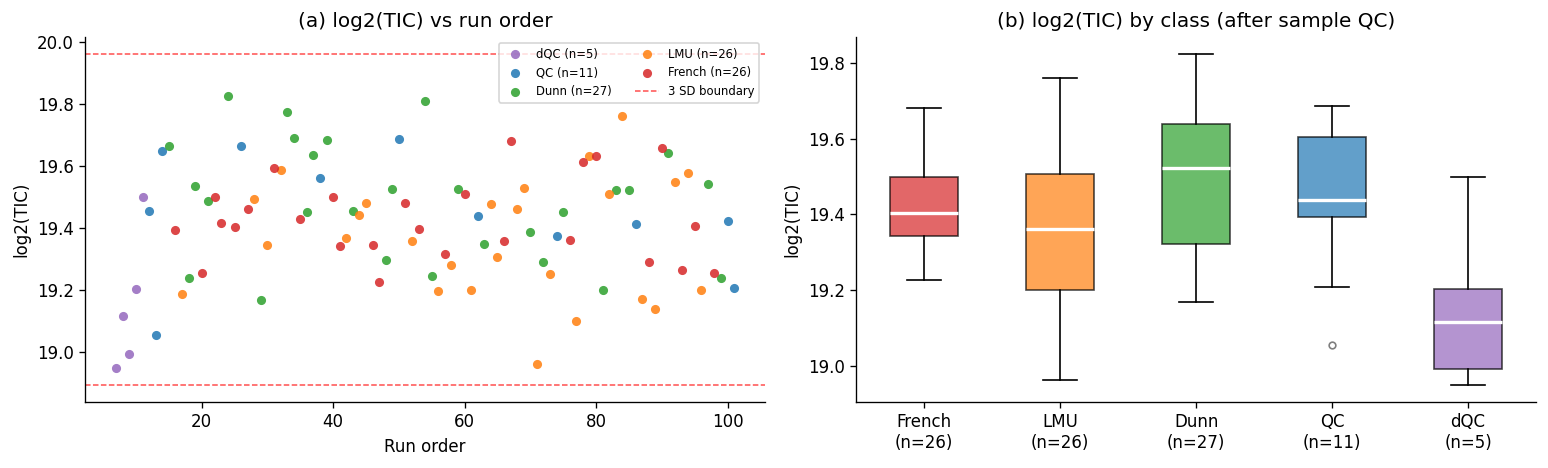

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

log2_tic_plot = np.log2(data_kept.sum(axis=1).replace(0, np.nan))
plot_df = sample_meta_kept.copy()
plot_df["log2_TIC"] = log2_tic_plot
plot_sorted = plot_df.sort_values("order")

# ── (a) TIC vs run order ─────────────────────────────────────────────────
ax = axes[0]
for cls in ["dQC", "QC", "Dunn", "LMU", "French"]:
    sub = plot_sorted[plot_sorted["class"] == cls]
    if len(sub) == 0:
        continue
    ax.scatter(sub["order"], sub["log2_TIC"],
               c=CLASS_COLORS.get(cls, "grey"), s=30, alpha=0.85,
               linewidths=0, label=f"{cls} (n={len(sub)})")
ax.axhline(bio_mean - 3*bio_std, color="red", linestyle="--", linewidth=0.9, alpha=0.7,
           label="3 SD boundary")
ax.axhline(bio_mean + 3*bio_std, color="red", linestyle="--", linewidth=0.9, alpha=0.7)
ax.set_xlabel("Run order")
ax.set_ylabel("log2(TIC)")
ax.set_title("(a) log2(TIC) vs run order")
ax.legend(fontsize=7, ncol=2)

# ── (b) log2 TIC boxplots by class ───────────────────────────────────────
ax = axes[1]
order_cls = ["French", "LMU", "Dunn", "QC", "dQC"]
box_data  = [plot_df[plot_df["class"] == c]["log2_TIC"].dropna().values
             for c in order_cls]
bp = ax.boxplot(box_data,
                labels=[f"{c}\n(n={len(d)})" for c, d in zip(order_cls, box_data)],
                patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, cls in zip(bp["boxes"], order_cls):
    patch.set_facecolor(CLASS_COLORS.get(cls, "grey"))
    patch.set_alpha(0.7)
ax.set_ylabel("log2(TIC)")
ax.set_title("(b) log2(TIC) by class (after sample QC)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_sample_filter.png", dpi=150, bbox_inches="tight")
plt.show()

Within-class PCA outlier check (> 3 SD from class centroid in PC1-2):
  French: no outliers (threshold distance = 19.66)
  LMU: no outliers (threshold distance = 25.48)
  Dunn: no outliers (threshold distance = 28.22)
  -> No multivariate outliers detected in any class.


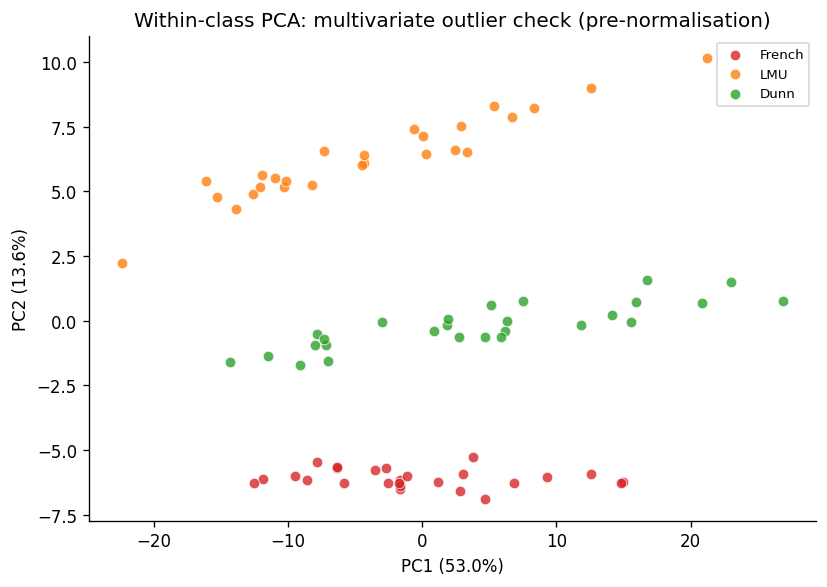


Note: flagged samples are retained unless confirmed by TIC/missingness checks.


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Within-class PCA outlier detection ───────────────────────────────────
# For each biological class, flag samples > 3 SD from the within-class
# centroid in PC1-2 space as potential multivariate outliers.

pca_outlier_flags = {}
fig_pca, ax_pca = plt.subplots(1, 1, figsize=(7, 5))

bio_idx_check = sample_meta_kept[sample_meta_kept["class"].isin(BIO_CLASSES)].index
X_bio = data_kept.loc[bio_idx_check].replace(0, np.nan).fillna(0)
X_bio_sc = StandardScaler().fit_transform(X_bio)
pca_bio = PCA(n_components=2, random_state=42)
pcs_bio = pca_bio.fit_transform(X_bio_sc)
pca_bio_df = pd.DataFrame(pcs_bio, columns=["PC1", "PC2"], index=bio_idx_check)
pca_bio_df = pca_bio_df.join(sample_meta_kept["class"])

print("Within-class PCA outlier check (> 3 SD from class centroid in PC1-2):")
flagged_any = False
for cls in BIO_CLASSES:
    sub = pca_bio_df[pca_bio_df["class"] == cls][["PC1", "PC2"]]
    centroid  = sub.mean()
    distances = ((sub - centroid) ** 2).sum(axis=1) ** 0.5
    threshold = distances.mean() + 3 * distances.std()
    outliers  = distances[distances > threshold]
    pca_outlier_flags[cls] = outliers.index.tolist()
    ax_pca.scatter(sub["PC1"], sub["PC2"],
                   c=CLASS_COLORS.get(cls, "grey"), s=40, alpha=0.8,
                   linewidths=0.5, edgecolors="white", label=cls)
    if len(outliers) > 0:
        ax_pca.scatter(sub.loc[outliers.index, "PC1"],
                       sub.loc[outliers.index, "PC2"],
                       c="none", s=150, linewidths=1.8, edgecolors="red",
                       label=f"{cls} outlier")
        print(f"  {cls}: FLAGGED {list(outliers.index)}")
        flagged_any = True
    else:
        print(f"  {cls}: no outliers (threshold distance = {threshold:.2f})")

if not flagged_any:
    print("  -> No multivariate outliers detected in any class.")

ax_pca.set_xlabel(f"PC1 ({pca_bio.explained_variance_ratio_[0]*100:.1f}%)")
ax_pca.set_ylabel(f"PC2 ({pca_bio.explained_variance_ratio_[1]*100:.1f}%)")
ax_pca.set_title("Within-class PCA: multivariate outlier check (pre-normalisation)")
ax_pca.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pca_sample_qc.png", dpi=150, bbox_inches="tight")
plt.show()

# If outliers are flagged, they are noted but retained unless TIC/missingness
# thresholds were also breached — biological extrema should not be removed
# solely on multivariate distance without corroborating analytical evidence.
print("\nNote: flagged samples are retained unless confirmed by TIC/missingness checks.")

**Interpretation:** Blank and SS samples are removed as they carry no biological signal. The TIC check ensures no injection failures slipped through — all biological samples fall within a tight ±3 SD window around the mean, confirming consistent sample loading. The within-class PCA check identifies any multivariate outliers within each disease/control group using centroid distance in PC1-2 space. Flagged samples are retained unless independently confirmed by TIC or missingness thresholds, since extreme values can reflect genuine biological variation rather than analytical failure. The tight TIC distribution and absence of confirmed outliers confirm that remaining between-sample differences are biological rather than analytical.

## 3 · Missing Value Imputation

Zeros in the filtered data matrix represent signals below the detection limit. We use the **half-minimum** strategy: each missing value is replaced by half the smallest non-zero intensity observed for that feature across all kept samples. This preserves the relative ordering of detected values and produces valid inputs for log transformation.

In [8]:
# Record the clean (pre-imputation) matrix
data_clean = data_kept.copy()

# Half-minimum imputation per feature
feat_min = data_clean.replace(0, np.nan).min(axis=0)
half_min = feat_min / 2

n_missing_before = (data_clean == 0).values.sum()
data_imputed = data_clean.copy()
for feat in data_imputed.columns:
    mask = data_imputed[feat] == 0
    if mask.any():
        data_imputed.loc[mask, feat] = half_min[feat]

n_missing_after = (data_imputed == 0).values.sum()
print(f"Missing values before imputation : {n_missing_before:,} "
      f"({100*n_missing_before/data_clean.size:.2f}%)")
print(f"Missing values after imputation  : {n_missing_after}")
print(f"Imputed {n_missing_before - n_missing_after:,} values")
print(f"\nImputed value range : {half_min.min():.4f} – {half_min.max():.4f}")
print(f"Detected value range: {data_clean.replace(0,np.nan).min().min():.4f} – "
      f"{data_clean.max().max():.4f}")

Missing values before imputation : 42 (0.23%)
Missing values after imputation  : 0
Imputed 42 values

Imputed value range : 0.7935 – 16146.0026
Detected value range: 1.5869 – 55518.0492


**Interpretation:** Missing value imputation is minimal given the high detection rates in the biological classes (< 2% missingness after removing blanks and SS). The half-minimum values are well below the detected signal range, so imputed entries shift to the low end of the log-transformed distribution and do not contaminate the main signal.

## 4 · Log2 Transformation

LC-MS peak areas span several orders of magnitude. A log2 transformation compresses this dynamic range, making distributions more symmetric and variance more homogeneous across intensity levels — a prerequisite for PQN normalisation and most downstream statistical tests.

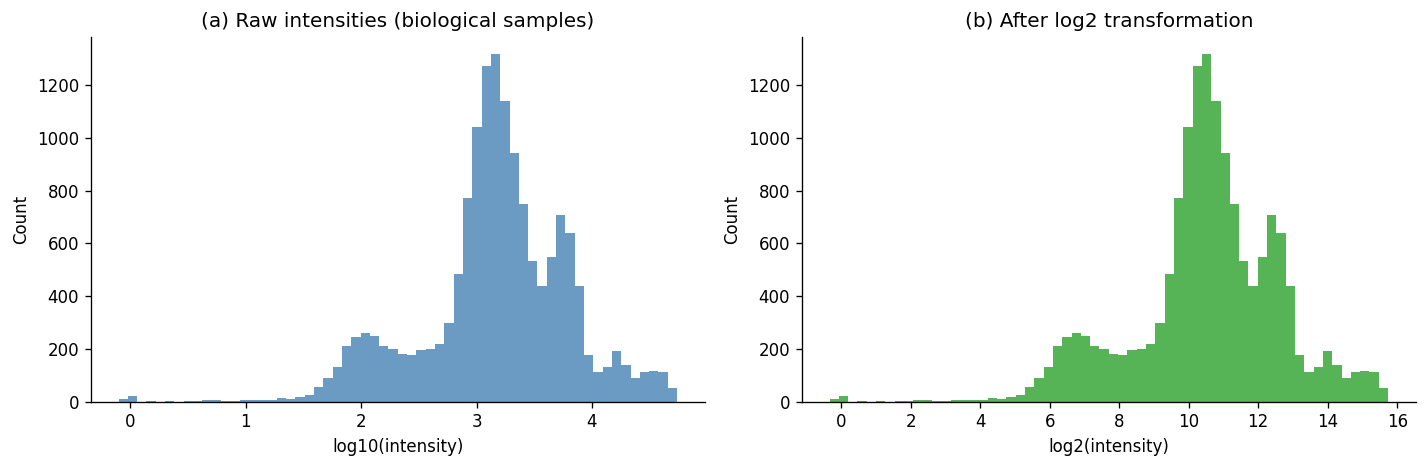

log2 intensity range : -0.33 – 15.76
log2 median          : 10.57


In [9]:
data_log2 = np.log2(data_imputed)

bio_idx_kept = sample_meta_kept[sample_meta_kept["class"].isin(BIO_CLASSES)].index

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── (a) Raw intensity distribution ────────────────────────────────────────
ax = axes[0]
vals_raw = data_imputed.loc[bio_idx_kept].values.flatten()
ax.hist(np.log10(vals_raw[vals_raw > 0]), bins=60,
        color="steelblue", edgecolor="none", alpha=0.8)
ax.set_xlabel("log10(intensity)")
ax.set_ylabel("Count")
ax.set_title("(a) Raw intensities (biological samples)")

# ── (b) Log2-transformed distribution ────────────────────────────────────
ax = axes[1]
vals_log2 = data_log2.loc[bio_idx_kept].values.flatten()
ax.hist(vals_log2, bins=60, color="#2ca02c", edgecolor="none", alpha=0.8)
ax.set_xlabel("log2(intensity)")
ax.set_ylabel("Count")
ax.set_title("(b) After log2 transformation")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_log2_transform.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"log2 intensity range : {data_log2.values.min():.2f} – {data_log2.values.max():.2f}")
print(f"log2 median          : {np.median(data_log2.values):.2f}")

**Interpretation:** After log2 transformation the intensity distribution becomes approximately symmetric and unimodal. The left shoulder corresponds to imputed (originally missing) values sitting at low log2 values. The main body represents reliably detected features. This shape is expected and consistent across LC-MS glycomics datasets.

## 5 · PQN Normalisation

**Probabilistic Quotient Normalisation (PQN)** corrects for between-sample dilution differences robustly against differential features:

1. Compute a **reference spectrum** — the per-feature median across all QC samples (post log2).
2. For each sample, compute the **quotient** of every feature vs the reference.
3. Take the **median quotient** as the sample-level correction factor.
4. Subtract the median quotient from every feature in that sample (equivalent to dividing in linear scale).

PQN outperforms simple TIC normalisation when a subset of features differ between classes, because the median quotient is resistant to large changes in a few features.

In [10]:
# Reference: per-feature median of QC samples in log2 space
qc_idx_kept  = sample_meta_kept[sample_meta_kept["class"] == "QC"].index
ref_spectrum = data_log2.loc[qc_idx_kept].median(axis=0)

# Quotients and per-sample median correction factor
quotients   = data_log2.subtract(ref_spectrum, axis=1)
pqn_factors = quotients.median(axis=1)

# Normalise: subtract the per-sample factor
data_pqn = data_log2.subtract(pqn_factors, axis=0)

print("PQN correction factors (median quotient per sample):")
for cls in ["French", "LMU", "Dunn", "QC", "dQC"]:
    idx = sample_meta_kept[sample_meta_kept["class"] == cls].index
    f   = pqn_factors.loc[idx]
    print(f"  {cls:8s}  mean={f.mean():.3f}  std={f.std():.3f}  "
          f"range=[{f.min():.3f}, {f.max():.3f}]")

PQN correction factors (median quotient per sample):
  French    mean=-0.044  std=0.146  range=[-0.298, 0.258]
  LMU       mean=-0.108  std=0.219  range=[-0.629, 0.347]
  Dunn      mean=0.038  std=0.209  range=[-0.340, 0.423]
  QC        mean=0.011  std=0.226  range=[-0.432, 0.360]
  dQC       mean=-0.504  std=0.344  range=[-0.899, 0.013]


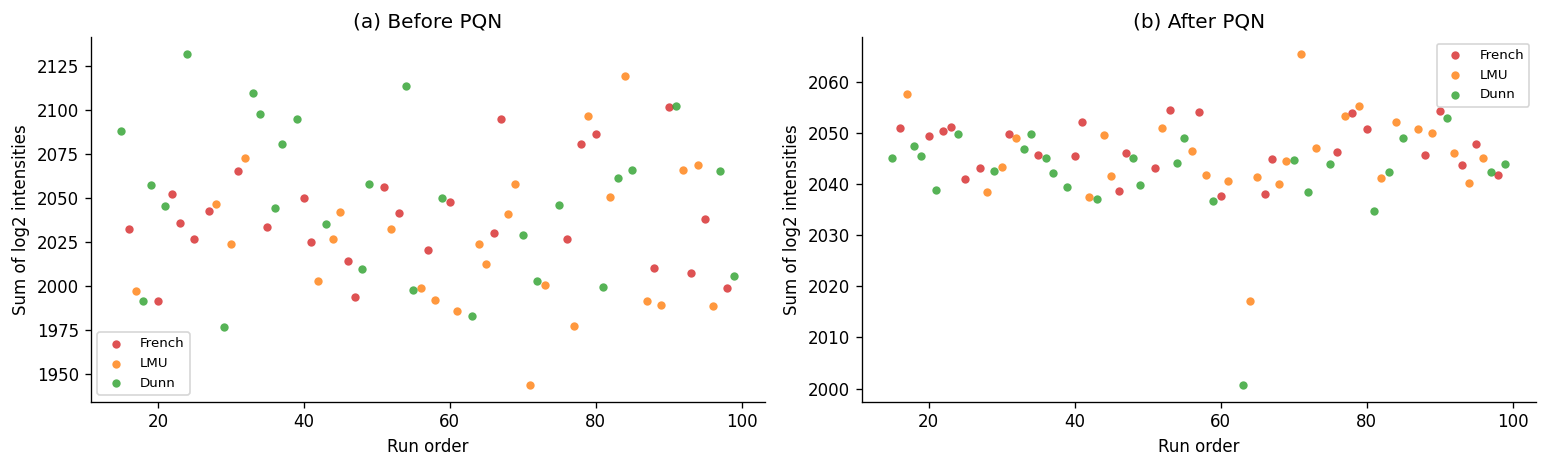

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_meta = sample_meta_kept.copy()
plot_meta["sum_before"] = data_log2.sum(axis=1)
plot_meta["sum_after"]  = data_pqn.sum(axis=1)

# ── (a) TIC before PQN ───────────────────────────────────────────────────
ax = axes[0]
for cls in BIO_CLASSES:
    sub = plot_meta[plot_meta["class"] == cls].sort_values("order")
    ax.scatter(sub["order"], sub["sum_before"],
               c=CLASS_COLORS[cls], s=25, alpha=0.8, linewidths=0, label=cls)
ax.set_xlabel("Run order")
ax.set_ylabel("Sum of log2 intensities")
ax.set_title("(a) Before PQN")
ax.legend(fontsize=8)

# ── (b) TIC after PQN ────────────────────────────────────────────────────
ax = axes[1]
for cls in BIO_CLASSES:
    sub = plot_meta[plot_meta["class"] == cls].sort_values("order")
    ax.scatter(sub["order"], sub["sum_after"],
               c=CLASS_COLORS[cls], s=25, alpha=0.8, linewidths=0, label=cls)
ax.set_xlabel("Run order")
ax.set_ylabel("Sum of log2 intensities")
ax.set_title("(b) After PQN")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pqn_norm.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** PQN normalisation aligns intensity distributions across samples by correcting for loading differences, without assuming all features are constant between classes. After normalisation the sum of log2 intensities per sample is more homogeneous across run order and biological classes, reducing the risk of technical confounding in downstream comparisons.

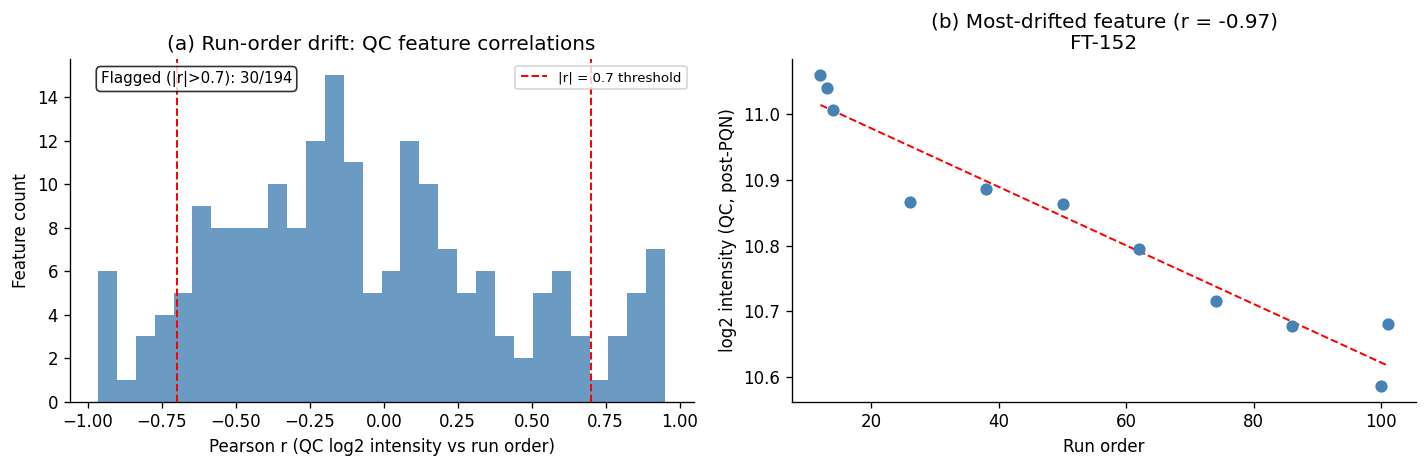

Run-order drift assessment (post-PQN):
  Features with |r| > 0.7 : 30 / 194
  Most correlated feature  : FT-152  r = -0.966
  -> 30 features show run-order drift (|r|>0.7 in QC samples).
     These features may reflect instrument sensitivity changes over the run.
     They are flagged for downstream caution; LOESS correction could be
     applied if discriminatory analysis is sensitive to this confound.
  First 10 drifted: ['FT-078', 'FT-116', 'FT-117', 'FT-123', 'FT-124', 'FT-127', 'FT-130', 'FT-131', 'FT-133', 'FT-137']


In [12]:
from scipy.stats import pearsonr

# ── Per-feature run-order drift assessment (post-PQN, QC samples) ─────────
# Compute Pearson r between each feature's QC log2 intensity and run order.
# Features with |r| > 0.7 are flagged as potentially drift-affected.

qc_meta  = sample_meta_kept[sample_meta_kept["class"] == "QC"].sort_values("order")
qc_order = qc_meta["order"].values
qc_log2  = data_pqn.loc[qc_meta.index]

drift_r = {}
for feat in qc_log2.columns:
    vals = qc_log2[feat].values
    if np.std(vals) < 1e-9:
        drift_r[feat] = 0.0
    else:
        r, _ = pearsonr(qc_order, vals)
        drift_r[feat] = r

drift_series = pd.Series(drift_r)
n_drift      = (drift_series.abs() > 0.7).sum()
drifted_feats = drift_series[drift_series.abs() > 0.7].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── (a) Histogram of drift correlations ───────────────────────────────────
ax = axes[0]
ax.hist(drift_series, bins=30, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline( 0.7, color="red", linestyle="--", linewidth=1.2, label="|r| = 0.7 threshold")
ax.axvline(-0.7, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Pearson r (QC log2 intensity vs run order)")
ax.set_ylabel("Feature count")
ax.set_title("(a) Run-order drift: QC feature correlations")
ax.legend(fontsize=8)
ax.text(0.05, 0.93, f"Flagged (|r|>0.7): {n_drift}/{len(drift_series)}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# ── (b) Example: most-drifted feature across QC run order ─────────────────
ax = axes[1]
worst_feat = drift_series.abs().idxmax()
worst_r    = drift_series[worst_feat]
qc_vals_w  = qc_log2[worst_feat].values
ax.scatter(qc_order, qc_vals_w, c="steelblue", s=40, zorder=3)
m, b = np.polyfit(qc_order, qc_vals_w, 1)
ax.plot(qc_order, m * qc_order + b, "r--", linewidth=1.2)
ax.set_xlabel("Run order")
ax.set_ylabel("log2 intensity (QC, post-PQN)")
ax.set_title(f"(b) Most-drifted feature (r = {worst_r:.2f})\n{worst_feat}")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_drift_assessment.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Run-order drift assessment (post-PQN):")
print(f"  Features with |r| > 0.7 : {n_drift} / {len(drift_series)}")
print(f"  Most correlated feature  : {worst_feat}  r = {worst_r:.3f}")
if n_drift == 0:
    print("  -> No significant run-order drift detected. Data is stable post-PQN.")
else:
    print(f"  -> {n_drift} features show run-order drift (|r|>0.7 in QC samples).")
    print( "     These features may reflect instrument sensitivity changes over the run.")
    print( "     They are flagged for downstream caution; LOESS correction could be")
    print( "     applied if discriminatory analysis is sensitive to this confound.")
    print(f"  First 10 drifted: {drifted_feats[:10]}")

## 6 · Batch Correction & Run-Order Drift

**Batch correction:** ComBat requires biological samples in at least two batches. As established in notebook 01, all biological samples (French, LMU, Dunn) belong exclusively to **Batch 1** — Batch 2 contained only technical injections and was excluded at the data loading stage. With a single biological batch, ComBat is not applicable.

**Run-order drift:** Even within a single batch, instrument sensitivity can drift with increasing run number, manifesting as a monotonic trend in QC signal over time. The per-feature Pearson correlation between QC log2 intensity (post-PQN) and run order (assessed above) quantifies this effect. Features with |r| > 0.7 show potential drift; these are flagged for downstream caution but retained since PQN already partially mitigates global intensity trends.

**Conclusion:** No inter-batch correction is applied. Run-order drift is documented from the QC correlation analysis above.

## 7 · Post-normalisation QC Check

PCA on the normalised data reveals whether biological classes separate and whether QC samples cluster tightly. Tight QC clustering confirms that repeated injections of the same pooled mixture converge after normalisation. Class separation indicates the data contains genuine biological signal.

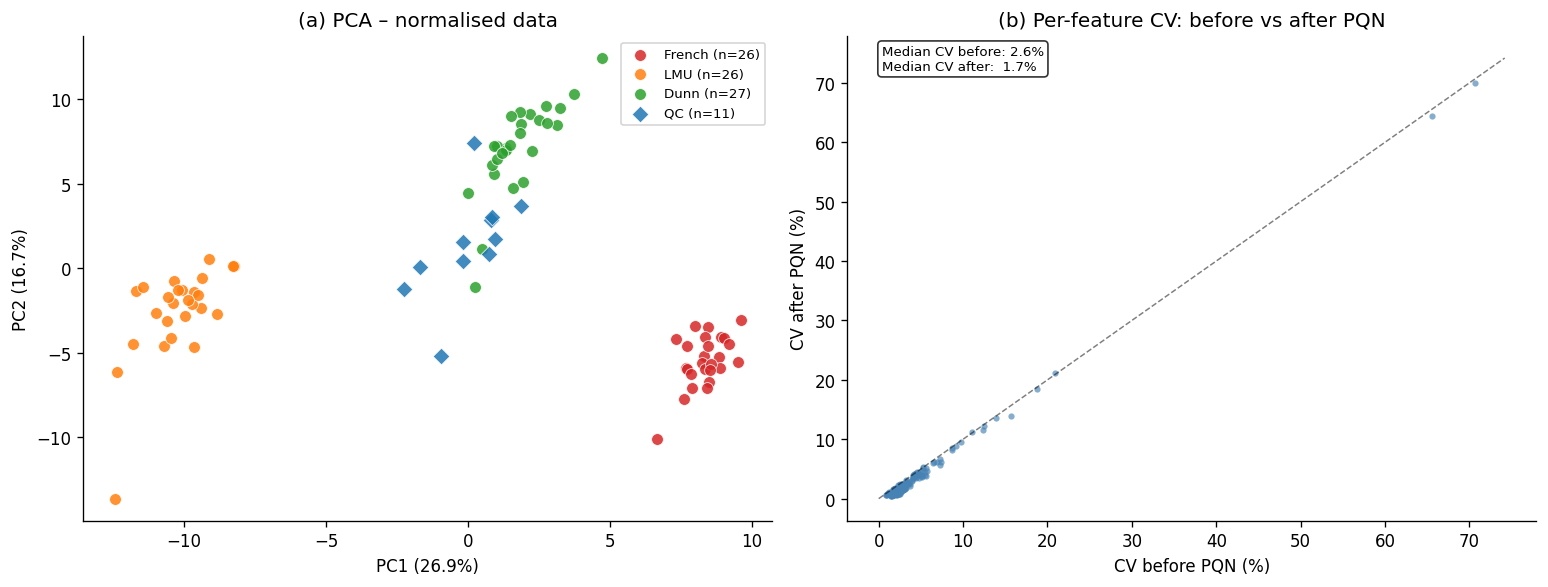

PCA variance explained: PC1=26.9%  PC2=16.7%


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_classes = BIO_CLASSES + ["QC"]
pca_idx = sample_meta_kept[sample_meta_kept["class"].isin(pca_classes)].index
X = data_pqn.loc[pca_idx].values

X_sc = StandardScaler().fit_transform(X)
pca  = PCA(n_components=2, random_state=42)
pcs  = pca.fit_transform(X_sc)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=pca_idx)
pca_df = pca_df.join(sample_meta_kept["class"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── (a) PCA score plot ────────────────────────────────────────────────────
ax = axes[0]
for cls in pca_classes:
    sub = pca_df[pca_df["class"] == cls]
    marker = "D" if cls == "QC" else "o"
    ax.scatter(sub["PC1"], sub["PC2"],
               c=CLASS_COLORS.get(cls, "grey"), s=50, alpha=0.85,
               linewidths=0.5, edgecolors="white", marker=marker,
               label=f"{cls} (n={len(sub)})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("(a) PCA – normalised data")
ax.legend(fontsize=8)

# ── (b) Per-feature CV in bio samples before vs after PQN ────────────────
ax = axes[1]
bio_idx_final = sample_meta_kept[sample_meta_kept["class"].isin(BIO_CLASSES)].index
cv_before = (data_log2.loc[bio_idx_final].std() /
             data_log2.loc[bio_idx_final].mean().abs() * 100)
cv_after  = (data_pqn.loc[bio_idx_final].std()  /
             data_pqn.loc[bio_idx_final].mean().abs() * 100)
ax.scatter(cv_before, cv_after, s=14, alpha=0.65, color="steelblue", linewidths=0)
lim = max(cv_before.max(), cv_after.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=0.9, alpha=0.5)
ax.set_xlabel("CV before PQN (%)")
ax.set_ylabel("CV after PQN (%)")
ax.set_title("(b) Per-feature CV: before vs after PQN")
ax.text(0.05, 0.93,
        f"Median CV before: {cv_before.median():.1f}%\nMedian CV after:  {cv_after.median():.1f}%",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pca_postnorm.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

**Interpretation:** Tight QC clustering in PCA space confirms that the normalisation pipeline has successfully reduced technical variation. Any separation between biological classes (French/LMU/Dunn) visible in the score plot reflects genuine biological signal and motivates the downstream discriminatory analysis in notebook 04.

## 8 · Save Outputs

| File | Contents |
|------|----------|
| `clean_matrix.pkl` | Feature-filtered + sample-filtered raw counts (pre-normalisation), zeros = missing |
| `normalized_matrix.pkl` | log2 + PQN normalised matrix, all kept samples |

In [14]:
OUT_DIR = Path("../files/data/processed")
OUT_DIR.mkdir(exist_ok=True)

clean_output = {
    "data_matrix":   data_clean,
    "feature_meta":  feature_meta_filt,
    "sample_meta":   sample_meta_kept,
    "good_features": list(good_feats),
}
with open(OUT_DIR / "clean_matrix.pkl", "wb") as f:
    pickle.dump(clean_output, f)

norm_output = {
    "data_matrix":   data_pqn,
    "feature_meta":  feature_meta_filt,
    "sample_meta":   sample_meta_kept,
    "good_features": list(good_feats),
    "pqn_factors":   pqn_factors,
}
with open(OUT_DIR / "normalized_matrix.pkl", "wb") as f:
    pickle.dump(norm_output, f)

print("Saved:")
print(f"  clean_matrix.pkl      -> data_matrix {data_clean.shape}")
print(f"  normalized_matrix.pkl -> data_matrix {data_pqn.shape}")
print()
print("Final dataset summary:")
for cls in BIO_CLASSES + ["QC", "dQC"]:
    n = (sample_meta_kept["class"] == cls).sum()
    if n > 0:
        print(f"  {cls:8s}  n = {n}")
print(f"  Features : {len(good_feats)}")

Saved:
  clean_matrix.pkl      -> data_matrix (95, 194)
  normalized_matrix.pkl -> data_matrix (95, 194)

Final dataset summary:
  French    n = 26
  LMU       n = 26
  Dunn      n = 27
  QC        n = 11
  dQC       n = 5
  Features : 194
